<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br><br><br>

# Listed Volatility and Variance Derivatives

**Wiley Finance (2017)**

Dr. Yves J. Hilpisch | The Python Quants GmbH

http://tpq.io | [@dyjh](http://twitter.com/dyjh) | http://books.tpq.io

<img src="https://hilpisch.com/images/lvvd_cover.png" alt="Listed Volatility and Variance Derivatives" width="30%" align="left" border="0">

# Trading and Settlement

## Introduction

This chapter covers practical aspects of trading Eurex variance futures. Among others, topics are:

* overview of major variance futures contract terms
* intraday trading and trade conventions
* trade matching at the end of the trading day
* different traded volatilities with their impact on margining
* after the trade matching until maturity
* further details about interest rate calculation and market disruption events

## Overview of Variance Futures Terms

The following listing provides an overview of the major terms of the Eurex variance futures contract. All technical terms are explained in chapter _Variance Futures_.

* **underlying**: realized variance of EURO STOXX 50 stock index 
* **interest rates**: Euribor for present value factor $DF_t$ and Eonia for $ARMVM_t$ 
* **standard strike**: determined on first trading day and equal to settled implied volatility for the relevant maturity
* **1st settlement price**: equal to 3,000 (i.e. for setting standard strike = settled implied variance)
* **contract value**: 1 EUR per variance futures point
* **minimum price change/tick value**: 0.0001 variance futures points and 0.0001 EUR
* **settlement**: in cash
* **terms**: next three month ends and the next three quarter end months thereafter as well as June and December thereafter
* **last trading day**: one day before final settlement day
* **final settlement day/expiration**: third Friday of maturity month
* **final settlement price**: based on the average index level of EURO STOXX 50 between 11:50 and 12:00 CET on final settlement day
* **trade matching**: variance futures trade in notional vega at volatility; upon matching notional vega and volatility are converted into variance futures and variance futures prices, respectively
* **continuous trading**: from 09:00 am until 5:30 pm CET on each trading day of Eurex
* **Eurex trade entry services**: from 6:30 pm until 9:00 pm CET on each trading day of Eurex
* **order maintainence**: notional vega at volatility, minimum order size 1 Vega, minimum price change 0.05 volatility points

## Intraday Trading

Variance futures are traded on-exchange in terms of notional vega at volatility. However, intraday there are no live futures prices quoted, they have to be calculated using live volatility quotes and the conversion parameters provided by Eurex. The conversion parameters are those used for the calculation of the settlement price from the previous day, except that the time-to-maturity $(T-t)$ is reduced by 1 day and the number of elapsed days $t$ is increased by 1 day.

Let us get back to the numerical example from section _Example Calculation_. The example simulates the calculation of daily settlement prices for a variance futures contract with inception on the 1st of June 2015 and a maturity on 19th of June 2015 (i.e. 15 trading days). Since we have saved the data, we can continue where we ended there.

In [1]:
import pandas as pd
h5 = pd.HDFStore('./data/var_data.h5', 'r')
data = h5['var_future']
h5.close()
data.head()

,SX5E,V6I1,2w,EONIA,R_t,sigma**2,t,DF_t,F_tS,ARMVM_t
Date,,,,,,,,,,
2015-06-01,3575.04,25.87,-0.108,-0.106,NaN,NaN,1,1.000038,3000.000000,0.000000
2015-06-02,3561.89,25.92,-0.109,-0.122,-0.003685,34.220799,2,1.000036,2917.569817,0.000000
2015-06-03,3583.82,25.80,-0.109,-0.143,0.006138,64.580457,3,1.000033,2876.127223,0.039897
2015-06-04,3556.38,26.24,-0.109,-0.138,-0.007686,92.677552,4,1.000030,2860.270332,0.110147
2015-06-05,3510.01,27.45,-0.109,-0.115,-0.013124,178.023718,5,1.000027,2892.229807,0.186585


We need to read out two central terms of the variance, namely the time-to-maturity in year fractions and the  standard volatility strike.

In [2]:
T = data['t'].iloc[-1]
T

np.int64(15)

In [3]:
sigma_K = data['V6I1'].iloc[0]
sigma_K

np.float64(25.87)

Similar to the calculation in section _Example Calculation_, we can now do the following calculation where we use the previous day's input parameters but today's remaining time-to-maturity and today's elapsed time (in days). 

In [4]:
data['F_ti'] = 3000.0
for t in data.index[2:]:
    data.loc[t, 'F_ti'] = data['DF_t'].shift(1)[t] * (
                    (data['t'][t]  * data['sigma**2'].shift(1)[t]
                  + (T - data['t'][t]) * data['V6I1'].shift(1)[t] ** 2) / T
                  - sigma_K ** 2) - data['ARMVM_t'].shift(1)[t] + 3000

The results are shown in the following table in the column ``F_ti`` for interim futures prices.

In [5]:
data

,SX5E,V6I1,2w,EONIA,R_t,sigma**2,t,DF_t,F_tS,ARMVM_t,F_ti
Date,,,,,,,,,,,
2015-06-01,3575.04,25.87,-0.108,-0.106,NaN,NaN,1,1.000038,3000.000000,0.000000,3000.000000
2015-06-02,3561.89,25.92,-0.109,-0.122,-0.003685,34.220799,2,1.000036,2917.569817,0.000000,3000.000000
2015-06-03,3583.82,25.80,-0.109,-0.143,0.006138,64.580457,3,1.000033,2876.127223,0.039897,2875.059930
2015-06-04,3556.38,26.24,-0.109,-0.138,-0.007686,92.677552,4,1.000030,2860.270332,0.110147,2836.055269
2015-06-05,3510.01,27.45,-0.109,-0.115,-0.013124,178.023718,5,1.000027,2892.229807,0.186585,2820.545132
2015-06-08,3468.31,27.30,-0.110,-0.127,-0.011951,214.408816,6,1.000025,2863.441596,0.235669,2853.863504
2015-06-09,3456.79,26.80,-0.110,-0.126,-0.003327,183.323049,7,1.000022,2799.046438,0.304354,2828.048644
2015-06-10,3526.48,25.86,-0.111,-0.117,0.019960,300.555651,8,1.000019,2802.709498,0.404654,2763.384526
2015-06-11,3551.91,26.39,-0.111,-0.120,0.007185,279.249096,9,1.000016,2776.365686,0.496044,2778.163430


As an example, assume that a trader buys on the 9th of June intraday 100,000 notional Vega at a traded implied volatility level of 26. The number of futures she has bought then is

\begin{eqnarray*}
futures &=& \frac{VegaNotional}{2 \cdot \sigma_{ti}} \cdot \frac{T}{T-t} \\
  &=& \frac{100000}{2 \cdot 26} \cdot \frac{15}{15-7} \\
  &=& 3605.77
\end{eqnarray*}

In [6]:
futures = 100000. / (2 * 26) * T / (T - data['t']['2015-06-09'])
futures

np.float64(3605.769230769231)

The intraday futures price for the variance futures contract is:

In [7]:
F_ti = data['F_ti']['2015-06-09']
F_ti

np.float64(2828.0486441054304)

The traded variance strike is

\begin{eqnarray*}
\sigma_t^2 &=& \frac{t \cdot \sigma_{0,t}^2 + (T - t) \cdot \sigma_{i}^2(t, T)  }{T} \\
     &=& \frac{7 \cdot 13.54^2 + (15 - 7) \cdot 26^2  }{15} \\
     &=& 446.08
\end{eqnarray*}

In [8]:
sigma_t2 = (data['t']['2015-06-09'] * data['sigma**2']['2015-06-09']
         + (T - data['t']['2015-06-09']) * 26 ** 2) / T
sigma_t2

np.float64(446.0840897506356)

The traded futures price then is

$$
F_t = DF_t \cdot \left(\sigma_t^2 -\sigma_{i}^2(t,T) \right) - ARMVM_t + 3000 = 2776.47
$$

In [9]:
F_t = (data['DF_t']['2015-06-09'] *
       (sigma_t2 - data['V6I1']['2015-06-01'] ** 2)
              - data['ARMVM_t']['2015-06-09'] + 3000)
F_t

np.float64(2776.517944016641)

Consequently, the trade has a value of:

In [10]:
P_ti = futures * F_t
P_ti

np.float64(10011482.971213851)

## Trade Matching

At the end of the day, the trade in notional vega and volatility is confirmed. Notional vega and volatility are, however, converted into variance futures at the variance futures settlement price. To this end, the intraday transaction gets cancelled and replaced by a confirmed transaction with the same number of futures but with the variance futures settlement price of the day.

In the example, we have

In [11]:
F_tS = data['F_tS']['2015-06-09']
F_tS

np.float64(2799.046437786436)

Consequently, the transaction booked has a value of:

In [12]:
P_t = futures * F_tS
P_t

np.float64(10092715.520864554)

The first margin payment given these numbers then is: 

In [13]:
P_t - P_ti

np.float64(81232.54965070263)

This is roughly the same as vega notional times the difference in settlement and traded volatility:

$$
margin = VegaNotional \cdot (\sigma_i - \sigma_{i}(t,T))
$$

In [14]:
100000 * (data['V6I1']['2015-06-09'] - 26)

np.float64(80000.00000000007)

## Different Traded Volatilities

Let us now see what impact different traded volatilities have on the first day margining of the same trade as before. The necessary parameters and values can be calculated in vectorized fashion. First, the array with the traded volatilities.

In [15]:
import numpy as np
trad_vols = np.arange(15, 25.01, 1)
trad_vols

array([15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.])

Second, the traded variance strikes.

In [16]:
sigma_t2 = (data['t']['2015-06-09'] * data['sigma**2']['2015-06-09']
         + (T - data['t']['2015-06-09']) * trad_vols ** 2) / T
sigma_t2

array([205.55075642, 222.08408975, 239.68408975, 258.35075642,
       278.08408975, 298.88408975, 320.75075642, 343.68408975,
       367.68408975, 392.75075642, 418.88408975])

Third, the traded futures prices.

In [17]:
F_t = (data['DF_t']['2015-06-09']
       * (sigma_t2 - data['V6I1']['2015-06-01'] ** 2)
               - data['ARMVM_t']['2015-06-09'] + 3000)
F_t

array([2535.97933866, 2552.51303437, 2570.11342013, 2588.78049594,
       2608.51426178, 2629.31471768, 2651.18186362, 2674.11569961,
       2698.11622564, 2723.18344172, 2749.31734785])

Fourth, the first day margins (P&L).

In [18]:
margins = futures * (F_tS - F_t)
margins

array([948559.25165039, 888942.56038212, 825479.6309675 , 758170.46340655,
       687015.05769926, 612013.41384563, 533165.53184566, 450471.41169935,
       363931.0534067 , 273544.45696771, 179311.62238237])

Let us visualize the results. The margins (P&L) are linear in traded volatility with the slope in the following figure being equal to the Vega notional of 100,000.

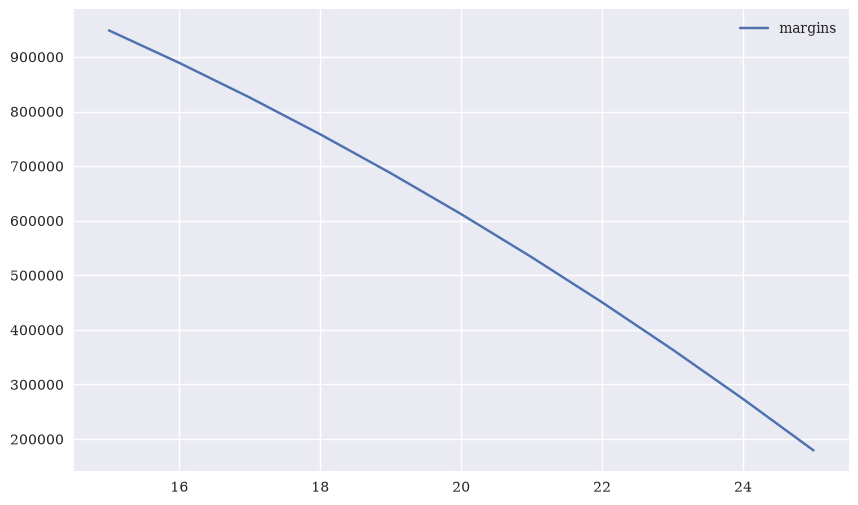

In [19]:
from pylab import mpl, plt
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
results = pd.DataFrame({'margins': margins}, index=trad_vols)
results.plot(figsize=(10, 6));

<p style="font-family: monospace;">Variance futures margins.

## After the Trade Matching

What happens after the trade matching until maturity? To this end, we can calculate the subsequent margins as follows. We start with the differences between settlement prices.

In [20]:
F_diffs = (data['F_tS'] - data['F_tS'].shift(1))
F_diffs

Date
2015-06-01          NaN
2015-06-02   -82.430183
2015-06-03   -41.442594
2015-06-04   -15.856891
2015-06-05    31.959475
2015-06-08   -28.788212
2015-06-09   -64.395158
2015-06-10     3.663060
2015-06-11   -26.343812
2015-06-12    50.900371
2015-06-15    85.221255
2015-06-16   -54.388986
2015-06-17   -93.702730
2015-06-18   -74.892447
2015-06-19   -81.502226
Name: F_tS, dtype: float64

With these differences, we can calculate the daily margins until maturity. 

In [21]:
margin_t = futures * F_diffs[F_diffs.index >= '2015-06-09']
margin_t

Date
2015-06-09   -232194.079193
2015-06-10     13208.148496
2015-06-11    -94989.706096
2015-06-12    183534.993356
2015-06-15    307288.178215
2015-06-16   -196114.130488
2015-06-17   -337870.420014
2015-06-18   -270044.881437
2015-06-19   -293878.218774
Name: F_tS, dtype: float64

The following code generates a pandas ``DataFrame`` object with the initial margins given the traded volatility strike and the subsequent margins until maturity.

In [22]:
results = pd.DataFrame(np.tile(margin_t, (len(trad_vols), 1)).T,
                       index=margin_t.index,
                       columns=trad_vols)
results.loc['2015-06-09', :] = margins  # setting the first day margins
np.round(results)

,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0
Date,,,,,,,,,,,
2015-06-09,948559.0,888943.0,825480.0,758170.0,687015.0,612013.0,533166.0,450471.0,363931.0,273544.0,179312.0
2015-06-10,13208.0,13208.0,13208.0,13208.0,13208.0,13208.0,13208.0,13208.0,13208.0,13208.0,13208.0
2015-06-11,-94990.0,-94990.0,-94990.0,-94990.0,-94990.0,-94990.0,-94990.0,-94990.0,-94990.0,-94990.0,-94990.0
2015-06-12,183535.0,183535.0,183535.0,183535.0,183535.0,183535.0,183535.0,183535.0,183535.0,183535.0,183535.0
2015-06-15,307288.0,307288.0,307288.0,307288.0,307288.0,307288.0,307288.0,307288.0,307288.0,307288.0,307288.0
2015-06-16,-196114.0,-196114.0,-196114.0,-196114.0,-196114.0,-196114.0,-196114.0,-196114.0,-196114.0,-196114.0,-196114.0
2015-06-17,-337870.0,-337870.0,-337870.0,-337870.0,-337870.0,-337870.0,-337870.0,-337870.0,-337870.0,-337870.0,-337870.0
2015-06-18,-270045.0,-270045.0,-270045.0,-270045.0,-270045.0,-270045.0,-270045.0,-270045.0,-270045.0,-270045.0,-270045.0
2015-06-19,-293878.0,-293878.0,-293878.0,-293878.0,-293878.0,-293878.0,-293878.0,-293878.0,-293878.0,-293878.0,-293878.0


The following figure visualizes the cumulative P&L (assuming zero interest rates) for the different traded volatility strikes.

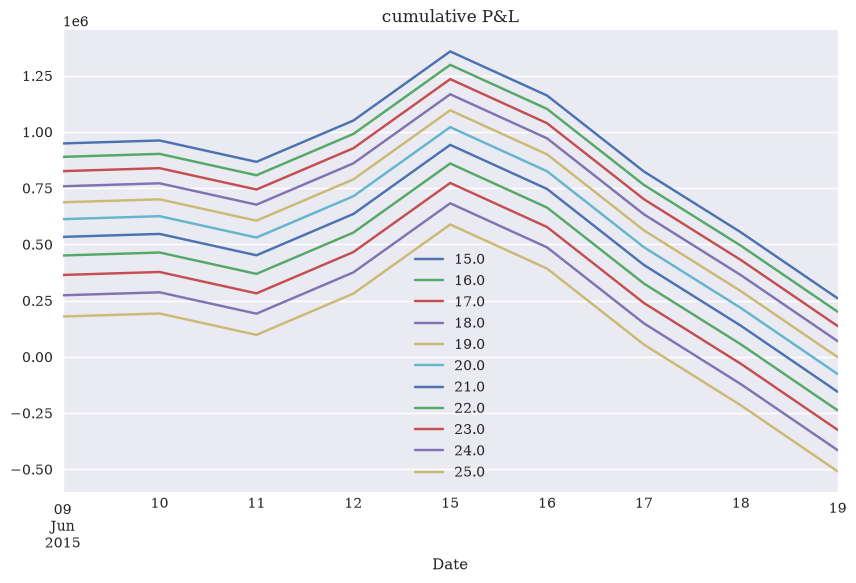

In [23]:
results.cumsum().plot(figsize=(10, 6), title='cumulative P&L');

<p style="font-family: monospace;">Cumulative P&L for variance future.

## Further Details

This section briefly discusses some further details of importance for the trading in Eurex variance futures.

### Interest Rate Calculation

ARMVM gets calculated based on the Eonia rate as settled at 7 pm CET on the previous day. The discount factors are calculated using the Euribor rates fixed at 11:00 am CET and interpolated to the respective maturities of the variance futures. The interpolation is done in linear fashion using the following formula:

$$
r_i = r(T_i) = \frac{T_{K+1}-T_i}{T_{K+1}-T_K}r(T_K) + \frac{T_i-T_K}{T_{K+1}-T_K}r(T_{K+1})
$$

where $T_{K+1}$ is maturity of the Euribor rate later than the futures maturity $T_i$, $T_K$ is the maturity of the Euribor rate before the futures maturity $T_i$.

### Market Disruption Events

There are three major market disruption events:

* STOXX fails to provide a market closing level for the EURO STOXX 50
* Eurex Exchange fails to open for trading during scheduled trading hours
* Other market disruption events according to the European OTC standard

## Conclusions

The major difference between listed variance futures and OTC variance swaps is that the former can be traded intraday. This chapter illustrates the major aspects that are important when it comes to the trading and settlement of these intraday-wise liquid instruments. Major concepts are the traded variance strike and the traded futures price. At the end of the day, the original intraday trade gets cancelled and the traded futures price gets replaced by the settlement price --- however, the number of futures remains the same.

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:team@tpq.io">team@tpq.io</a>